Saved network: Tripartite_Phyto-Gene-Pathway_network_300dpi.png
Saved: edges_phytochemical_gene.csv, edges_gene_pathway.csv


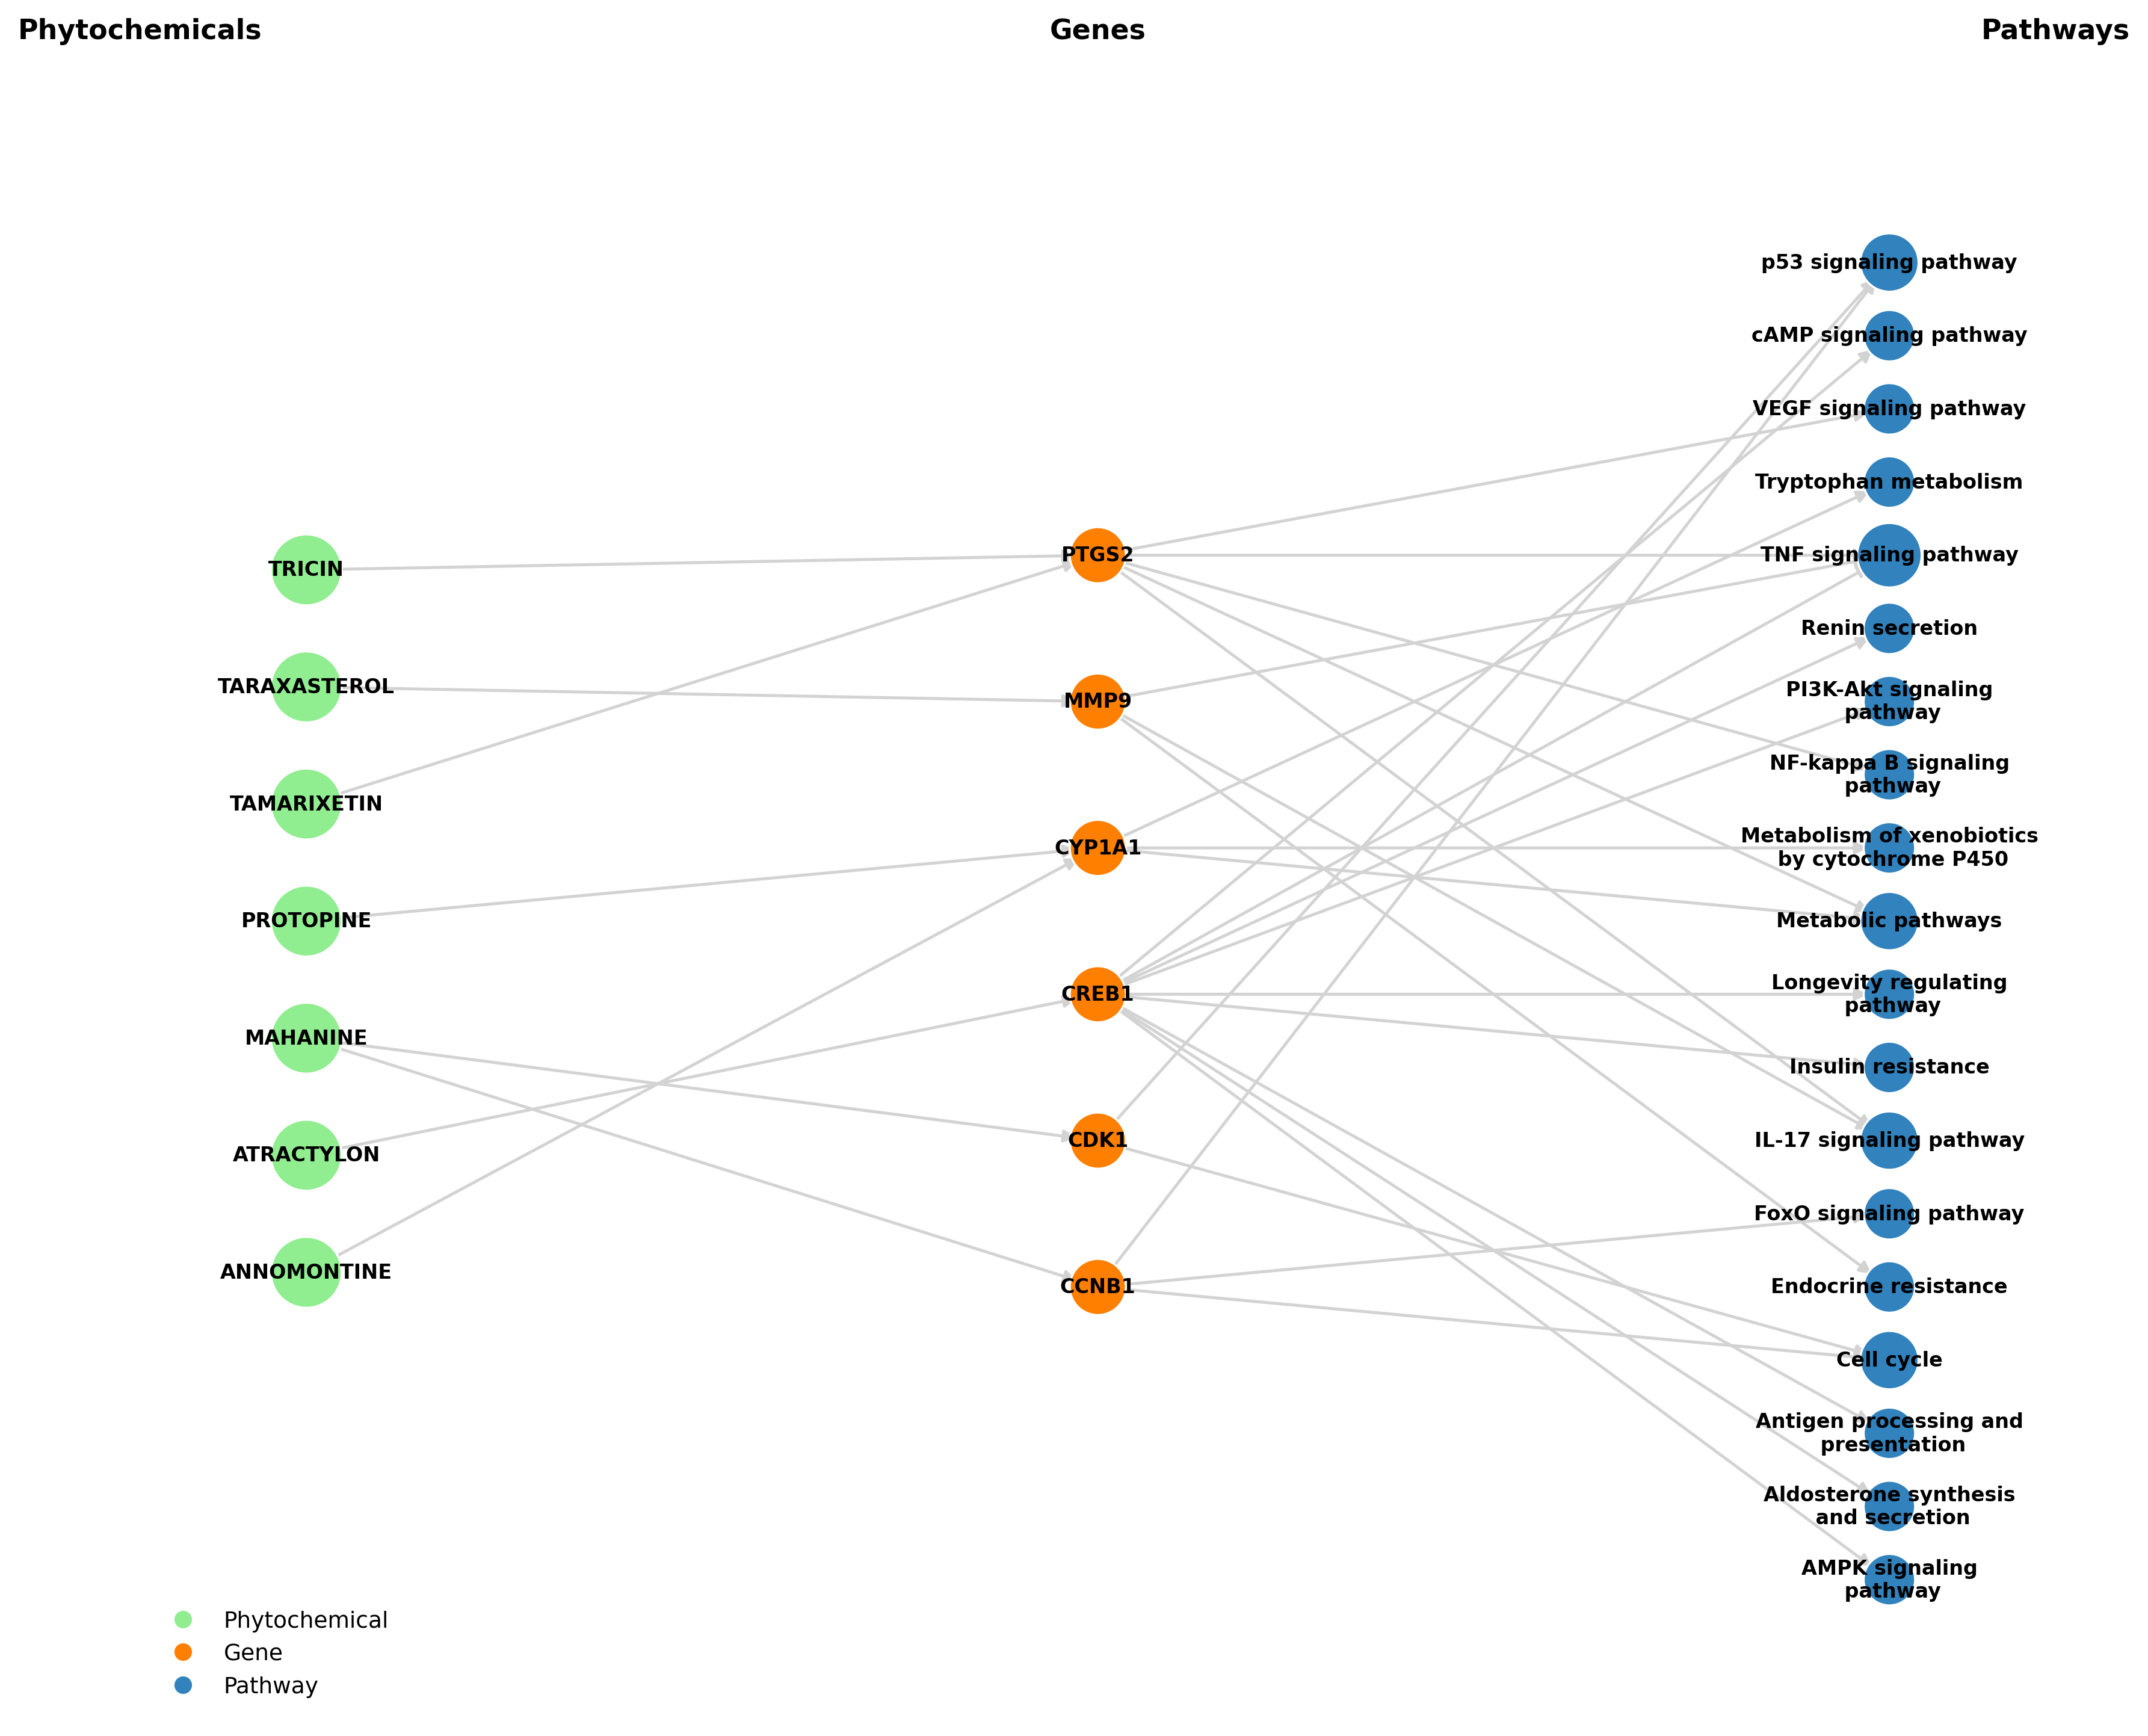

In [ ]:
# -*- coding: utf-8 -*-
# Tripartite network: Phytochemicals → Genes → Pathways
# - Directed edges
# - 3-column layout with colored nodes
# - 300 DPI output + CSV edgelists

import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.lines import Line2D

# -----------------------------
# 1) Data
# -----------------------------
# A) Phytochemical → Gene edges
chem_gene_edges = [
    ("Mahanine",     "CCNB1"),
    ("Mahanine",     "CDK1"),
    ("Taraxasterol", "MMP9"),
    ("Tricin",       "PTGS2"),
    ("Tamarixetin",  "PTGS2"),
    ("Annomontine",  "CYP1A1"),
    ("Protopine",    "CYP1A1"),
    ("Atractylon",   "CREB1"),
]

# B) Gene → Pathway edges (from your list)
gene_pathway_edges = [
    ("CREB1", "Aldosterone synthesis\n and secretion"),
    ("CREB1", "AMPK signaling\n pathway"),
    ("CREB1", "Antigen processing and\n presentation"),
    ("CREB1", "cAMP signaling pathway"),
    ("CCNB1", "Cell cycle"),
    ("CDK1",  "Cell cycle"),
    ("MMP9",  "Endocrine resistance"),
    ("CCNB1", "FoxO signaling pathway"),
    ("MMP9",  "IL-17 signaling pathway"),
    ("PTGS2", "IL-17 signaling pathway"),
    ("CREB1", "Insulin resistance"),
    ("CREB1", "Longevity regulating\n pathway"),
    ("PTGS2", "Metabolic pathways"),
    ("CYP1A1","Metabolic pathways"),
    ("CYP1A1","Metabolism of xenobiotics\n by cytochrome P450"),
    ("PTGS2", "NF-kappa B signaling\n pathway"),
    ("CCNB1", "p53 signaling pathway"),
    ("CDK1",  "p53 signaling pathway"),
    ("CREB1", "PI3K-Akt signaling\n pathway"),
    ("CREB1", "Renin secretion"),
    ("MMP9",  "TNF signaling pathway"),
    ("PTGS2", "TNF signaling pathway"),
    ("CREB1", "TNF signaling pathway"),
    ("CYP1A1","Tryptophan metabolism"),
    ("PTGS2", "VEGF signaling pathway"),
]

# -----------------------------
# 2) Build directed graph
# -----------------------------
G = nx.DiGraph()

# Node sets
chemicals = sorted({c for c, g in chem_gene_edges})
genes      = sorted({g for _, g in chem_gene_edges} |
                    {g for g, _ in gene_pathway_edges})
pathways   = sorted({p for _, p in gene_pathway_edges})

# Add nodes with a "layer" attribute for layout
G.add_nodes_from(chemicals, layer="Phytochemical")
G.add_nodes_from(genes,      layer="Gene")
G.add_nodes_from(pathways,   layer="Pathway")

# Add edges
G.add_edges_from(chem_gene_edges)       # chemical → gene
G.add_edges_from(gene_pathway_edges)    # gene → pathway

# -----------------------------
# 3) Columnar layout (x,y)
# -----------------------------
def column_positions(items, x_value, spacing=0.1):
    """Return evenly spaced y-positions for nodes listed in 'items' at x = x_value."""
    n = len(items)
    if n == 1:
        ys = [0.5]
    else:
        ys = np.linspace(0.5 - spacing * (n - 1) / 2, 0.5 + spacing * (n - 1) / 2, n)
    return {item: (x_value, y) for item, y in zip(items, ys)}

pos = {}
pos.update(column_positions(chemicals, x_value=0.1, spacing=0.08)) # Further adjusted spacing for chemicals
pos.update(column_positions(genes,      x_value=0.5, spacing=0.1)) # Kept spacing for genes
pos.update(column_positions(pathways,   x_value=0.9, spacing=0.05)) # Adjusted x_value and kept spacing for pathways


# -----------------------------
# 4) Styling
# -----------------------------
color_map = {
    "Phytochemical": "#90EE90",  # light green
    "Gene":          "#ff7f00",  # orange
    "Pathway":       "#3182bd",  # blue
}
node_colors = [color_map[G.nodes[n]["layer"]] for n in G.nodes()]

# Set node sizes
node_sizes = []
for n in G.nodes():
    if G.nodes[n]["layer"] == "Phytochemical":
        node_sizes.append(800)  # Increased size for phytochemicals
    elif G.nodes[n]["layer"] == "Gene":
        node_sizes.append(500)  # Equal size for genes
    else:
        node_sizes.append(300 + 120 * G.degree(n)) # Degree-scaled for pathways


# -----------------------------
# 5) Draw
# -----------------------------
# Figure size scales with largest column; keep compact but readable
max_column = max(len(chemicals), len(genes), len(pathways))
height = max(6, min(12, 0.35 * max_column + 3)) # Increased height slightly
width = 12 # Increased width slightly
fig, ax = plt.subplots(figsize=(width, height), dpi=300)


# Nodes
nx.draw_networkx_nodes(
    G, pos, node_size=node_sizes, node_color=node_colors,
    edgecolors="white", linewidths=0.8, ax=ax
)

# Edges (directed arrows)
nx.draw_networkx_edges(
    G, pos, edge_color="#d3d3d3", width=1.2, arrows=True, # Changed edge_color to light grey
    arrowstyle="-|>", arrowsize=10, connectionstyle="arc3,rad=0.0", ax=ax
)

# Labels: small & bold, capitalize phytochemical labels
label_opts = dict(font_size=8, font_weight="bold")
labels = {}
for node in G.nodes():
    if G.nodes[node]["layer"] == "Phytochemical":
        labels[node] = node.upper()
    else:
        labels[node] = node

nx.draw_networkx_labels(G, pos, labels=labels, ax=ax, **label_opts)

# Column headers
ax.text(0.00, 1.05, "Phytochemicals", ha="center", va="bottom",
        fontsize=11, fontweight="bold", transform=ax.transAxes)
ax.text(0.50, 1.05, "Genes", ha="center", va="bottom",
        fontsize=11, fontweight="bold", transform=ax.transAxes)
ax.text(1.00, 1.05, "Pathways", ha="center", va="bottom",
        fontsize=11, fontweight="bold", transform=ax.transAxes)

# Legend
legend_handles = [
    Line2D([0], [0], marker='o', color='w', label='Phytochemical',
           markerfacecolor=color_map["Phytochemical"], markersize=8),
    Line2D([0], [0], marker='o', color='w', label='Gene',
           markerfacecolor=color_map["Gene"], markersize=8),
    Line2D([0], [0], marker='o', color='w', label='Pathway',
           markerfacecolor=color_map["Pathway"], markersize=8),
]
ax.legend(handles=legend_handles, loc="lower left", frameon=False, fontsize=9)

ax.set_axis_off()
plt.tight_layout()

# -----------------------------
# 6) Save figure + edgelists
# -----------------------------
out_png = "Tripartite_Phyto-Gene-Pathway_network_300dpi.png"
plt.savefig(out_png, dpi=300, bbox_inches="tight")
print(f"Saved network: {out_png}")

# Optional: export edges for Cytoscape/Gephi
pd.DataFrame(chem_gene_edges, columns=["source_phytochemical", "target_gene"]) \
  .to_csv("edges_phytochemical_gene.csv", index=False)
pd.DataFrame(gene_pathway_edges, columns=["source_gene", "target_pathway"]) \
  .to_csv("edges_gene_pathway.csv", index=False)
print("Saved: edges_phytochemical_gene.csv, edges_gene_pathway.csv")

✅ Saved clean figure: Tripartite_PhytoGenePathway_FINAL_300dpi.png
✅ Saved: edges_Phytochemical_Gene.csv & edges_Gene_Pathway.csv


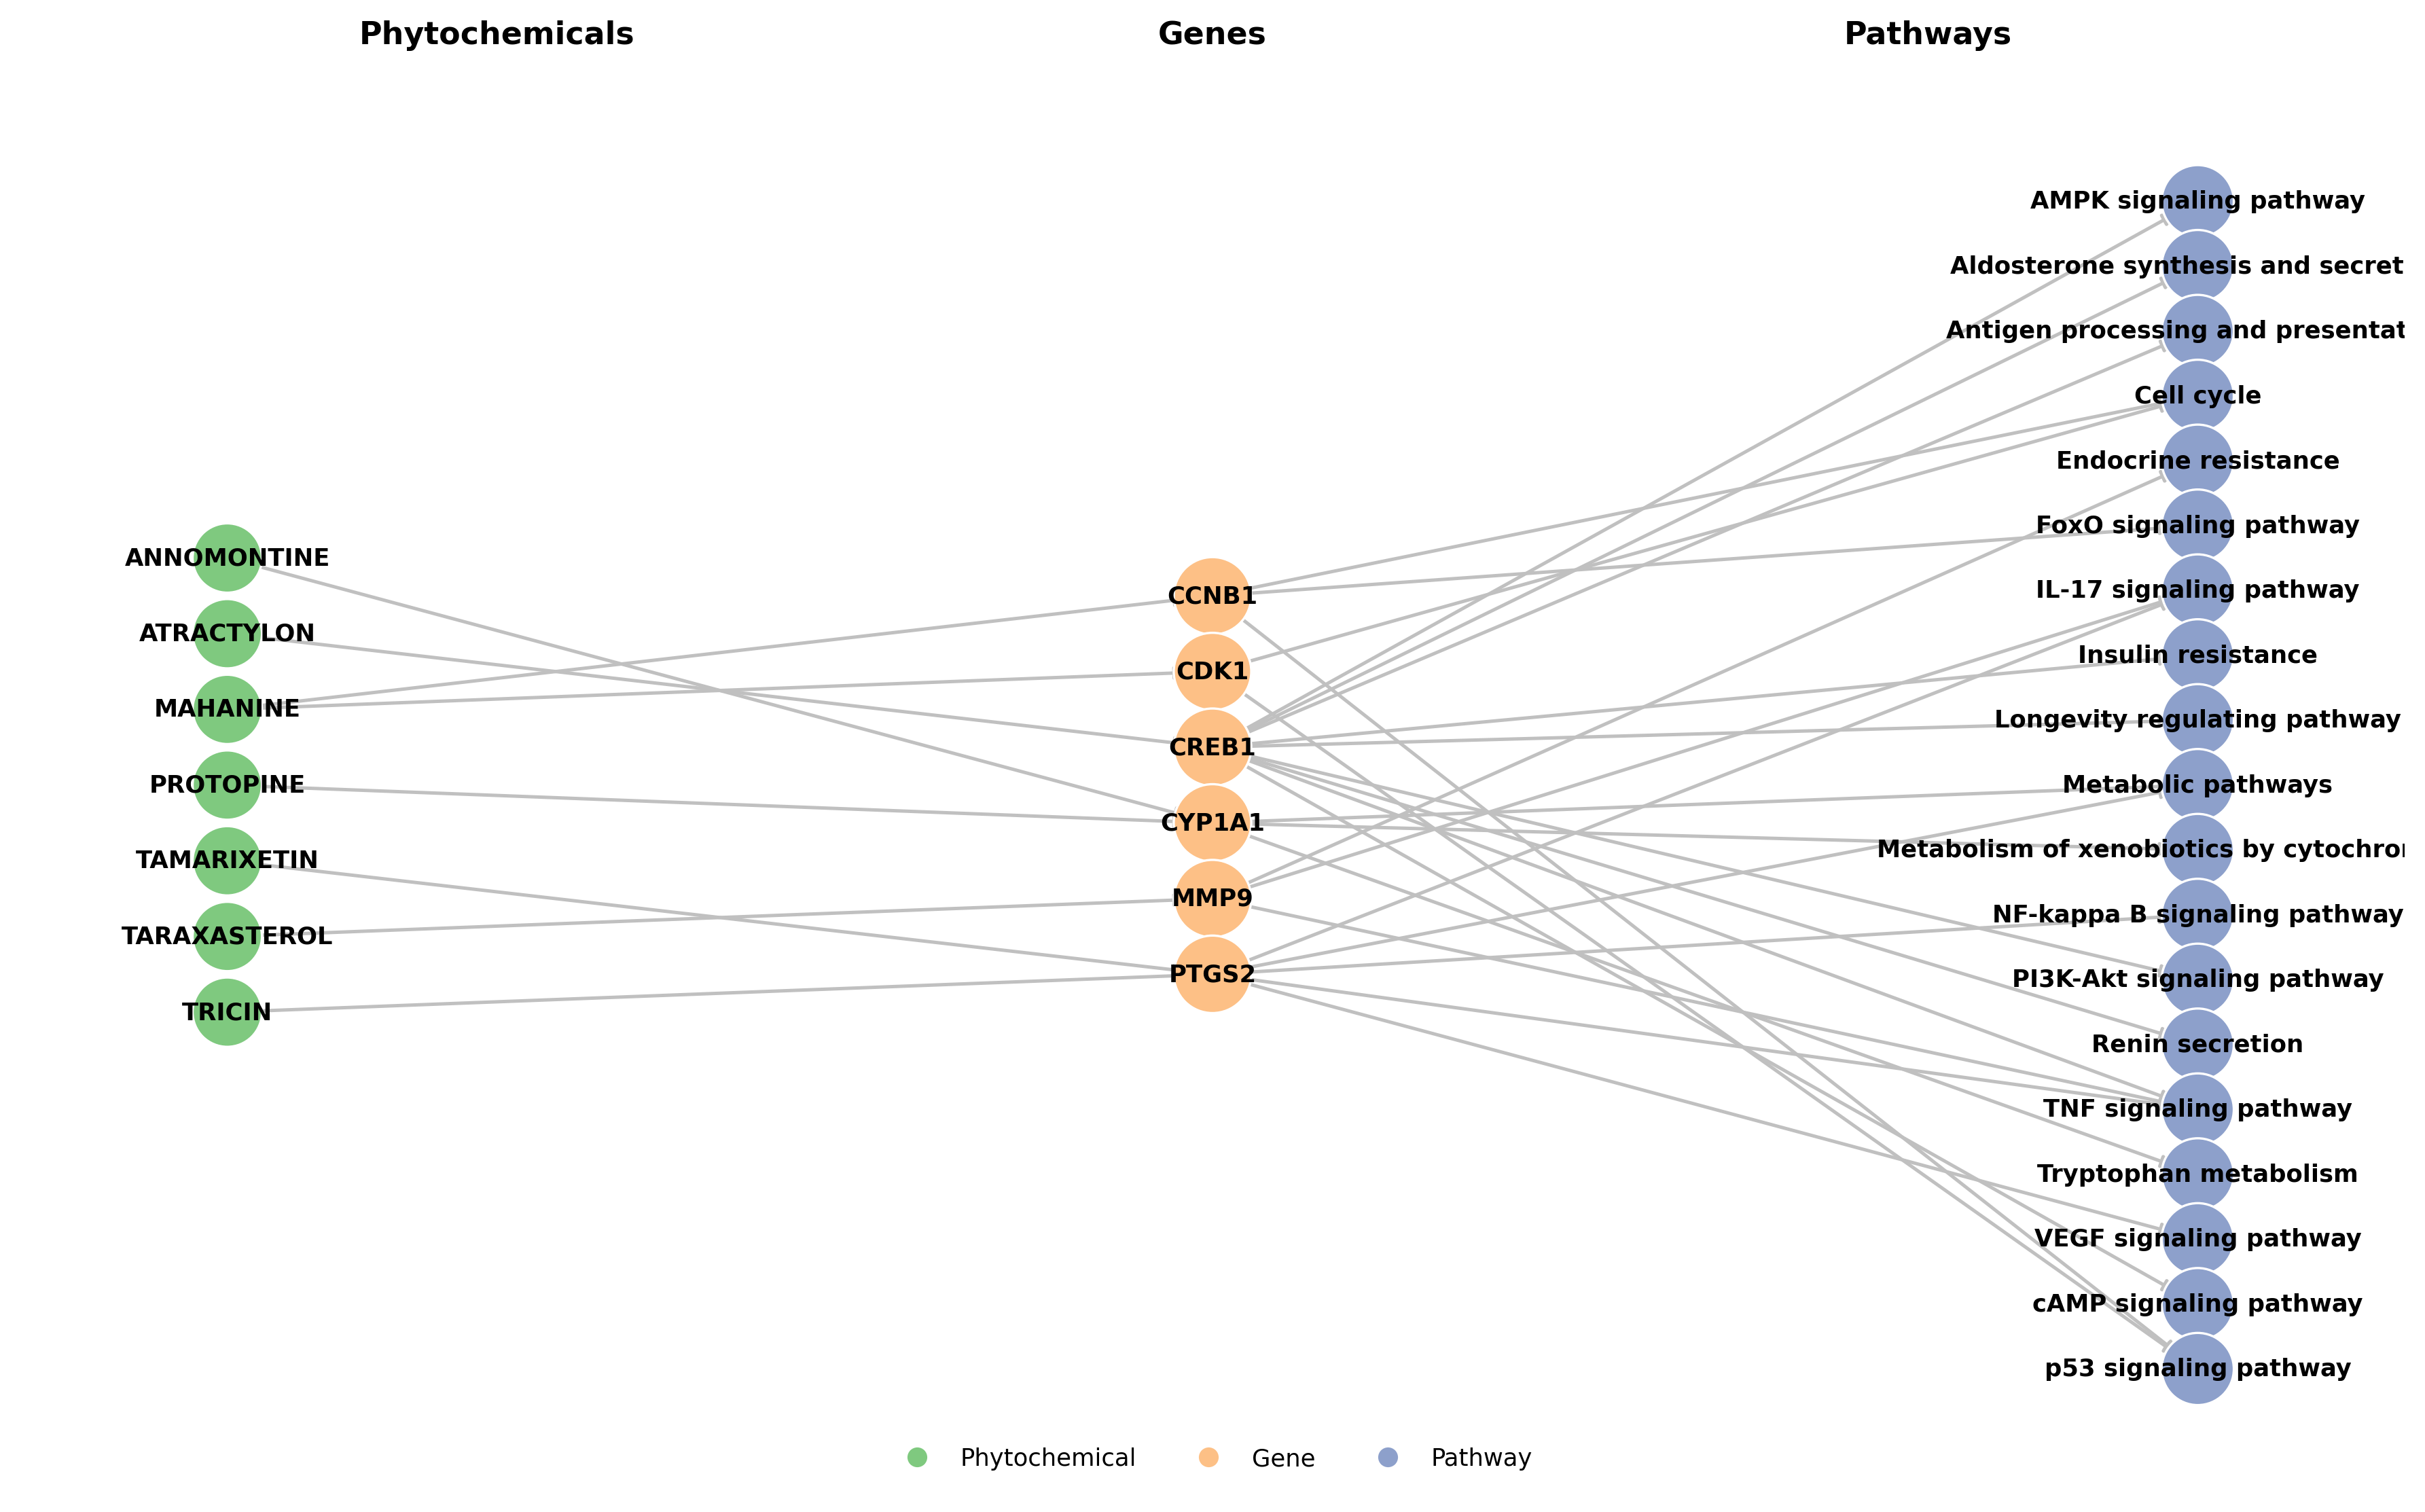

In [ ]:
# -*- coding: utf-8 -*-
# Clean & compact tripartite network for publication (Phytochemical → Gene → Pathway)
# - Even spacing, no text cutoffs
# - Light grey edges
# - No shadows
# - 300 DPI, journal-ready layout

import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.lines import Line2D

# -----------------------------
# 1) Data
# -----------------------------
chem_gene_edges = [
    ("Mahanine",     "CCNB1"),
    ("Mahanine",     "CDK1"),
    ("Taraxasterol", "MMP9"),
    ("Tricin",       "PTGS2"),
    ("Tamarixetin",  "PTGS2"),
    ("Annomontine",  "CYP1A1"),
    ("Protopine",    "CYP1A1"),
    ("Atractylon",   "CREB1"),
]

gene_pathway_edges = [
    ("CREB1", "Aldosterone synthesis and secretion"),
    ("CREB1", "AMPK signaling pathway"),
    ("CREB1", "Antigen processing and presentation"),
    ("CREB1", "cAMP signaling pathway"),
    ("CCNB1", "Cell cycle"),
    ("CDK1",  "Cell cycle"),
    ("MMP9",  "Endocrine resistance"),
    ("CCNB1", "FoxO signaling pathway"),
    ("MMP9",  "IL-17 signaling pathway"),
    ("PTGS2", "IL-17 signaling pathway"),
    ("CREB1", "Insulin resistance"),
    ("CREB1", "Longevity regulating pathway"),
    ("PTGS2", "Metabolic pathways"),
    ("CYP1A1","Metabolic pathways"),
    ("CYP1A1","Metabolism of xenobiotics by cytochrome P450"),
    ("PTGS2", "NF-kappa B signaling pathway"),
    ("CCNB1", "p53 signaling pathway"),
    ("CDK1",  "p53 signaling pathway"),
    ("CREB1", "PI3K-Akt signaling pathway"),
    ("CREB1", "Renin secretion"),
    ("MMP9",  "TNF signaling pathway"),
    ("PTGS2", "TNF signaling pathway"),
    ("CREB1", "TNF signaling pathway"),
    ("CYP1A1","Tryptophan metabolism"),
    ("PTGS2", "VEGF signaling pathway"),
]

# -----------------------------
# 2) Build directed graph
# -----------------------------
G = nx.DiGraph()

chemicals = sorted({c for c, _ in chem_gene_edges})
genes     = sorted({g for _, g in chem_gene_edges} | {g for g, _ in gene_pathway_edges})
pathways  = sorted({p for _, p in gene_pathway_edges})

G.add_nodes_from(chemicals, layer="Phytochemical")
G.add_nodes_from(genes,     layer="Gene")
G.add_nodes_from(pathways,  layer="Pathway")
G.add_edges_from(chem_gene_edges)
G.add_edges_from(gene_pathway_edges)

# -----------------------------
# 3) Layout: compact but readable
# -----------------------------
def column_positions(items, x_value, spacing=0.06):
    n = len(items)
    if n == 1:
        ys = [0.5]
    else:
        ys = np.linspace(0.5 + spacing*(n-1)/2, 0.5 - spacing*(n-1)/2, n)
    return {item: (x_value, y) for item, y in zip(items, ys)}

pos = {}
pos.update(column_positions(chemicals, x_value=0.2, spacing=0.07))   # left column
pos.update(column_positions(genes,     x_value=0.5, spacing=0.07))   # middle column
pos.update(column_positions(pathways,  x_value=0.8, spacing=0.06))   # right column

# -----------------------------
# 4) Styling
# -----------------------------
color_map = {
    "Phytochemical": "#7FC97F",  # green
    "Gene":          "#FDC086",  # orange
    "Pathway":       "#8DA0CB",  # blue
}
node_colors = [color_map[G.nodes[n]["layer"]] for n in G.nodes()]

# consistent, publication-style node sizes
node_sizes = []
for n in G.nodes():
    if G.nodes[n]["layer"] == "Phytochemical":
        node_sizes.append(600)
    elif G.nodes[n]["layer"] == "Gene":
        node_sizes.append(750)
    else:
        node_sizes.append(650)

# -----------------------------
# 5) Draw
# -----------------------------
fig, ax = plt.subplots(figsize=(12, 7.5), dpi=300)

# Edges - smooth, light grey
nx.draw_networkx_edges(
    G, pos, edge_color="#c0c0c0", width=1.2, arrows=True,
    arrowstyle="-|>", arrowsize=9, connectionstyle="arc3,rad=0.0", ax=ax
)

# Nodes
nx.draw_networkx_nodes(
    G, pos, node_size=node_sizes, node_color=node_colors,
    edgecolors="white", linewidths=0.8, ax=ax
)

# Labels - properly spaced and bold
labels = {}
for n in G.nodes():
    labels[n] = n.upper() if G.nodes[n]["layer"] == "Phytochemical" else n
nx.draw_networkx_labels(G, pos, labels=labels, font_size=8.5, font_weight="bold", ax=ax)

# Column headers
ax.text(0.2, 1.02, "Phytochemicals", ha="center", va="bottom",
        fontsize=11, fontweight="bold", transform=ax.transAxes)
ax.text(0.5, 1.02, "Genes", ha="center", va="bottom",
        fontsize=11, fontweight="bold", transform=ax.transAxes)
ax.text(0.8, 1.02, "Pathways", ha="center", va="bottom",
        fontsize=11, fontweight="bold", transform=ax.transAxes)

# Legend (bottom right)
legend_handles = [
    Line2D([0], [0], marker='o', color='w', label='Phytochemical',
           markerfacecolor=color_map["Phytochemical"], markersize=8),
    Line2D([0], [0], marker='o', color='w', label='Gene',
           markerfacecolor=color_map["Gene"], markersize=8),
    Line2D([0], [0], marker='o', color='w', label='Pathway',
           markerfacecolor=color_map["Pathway"], markersize=8),
]
ax.legend(handles=legend_handles, loc="lower center", frameon=False, fontsize=8.5, ncol=3)

ax.set_axis_off()
plt.tight_layout()

# -----------------------------
# 6) Save
# -----------------------------
out_png = "Tripartite_PhytoGenePathway_FINAL_300dpi.png"
plt.savefig(out_png, dpi=300, bbox_inches="tight")
print(f"✅ Saved clean figure: {out_png}")

# Export edge tables (optional)
pd.DataFrame(chem_gene_edges, columns=["Phytochemical", "Gene"]).to_csv("edges_Phytochemical_Gene.csv", index=False)
pd.DataFrame(gene_pathway_edges, columns=["Gene", "Pathway"]).to_csv("edges_Gene_Pathway.csv", index=False)
print("✅ Saved: edges_Phytochemical_Gene.csv & edges_Gene_Pathway.csv")


✅ Saved: Tripartite_PhytoGenePathway_SHORT_EDGES_300dpi.png


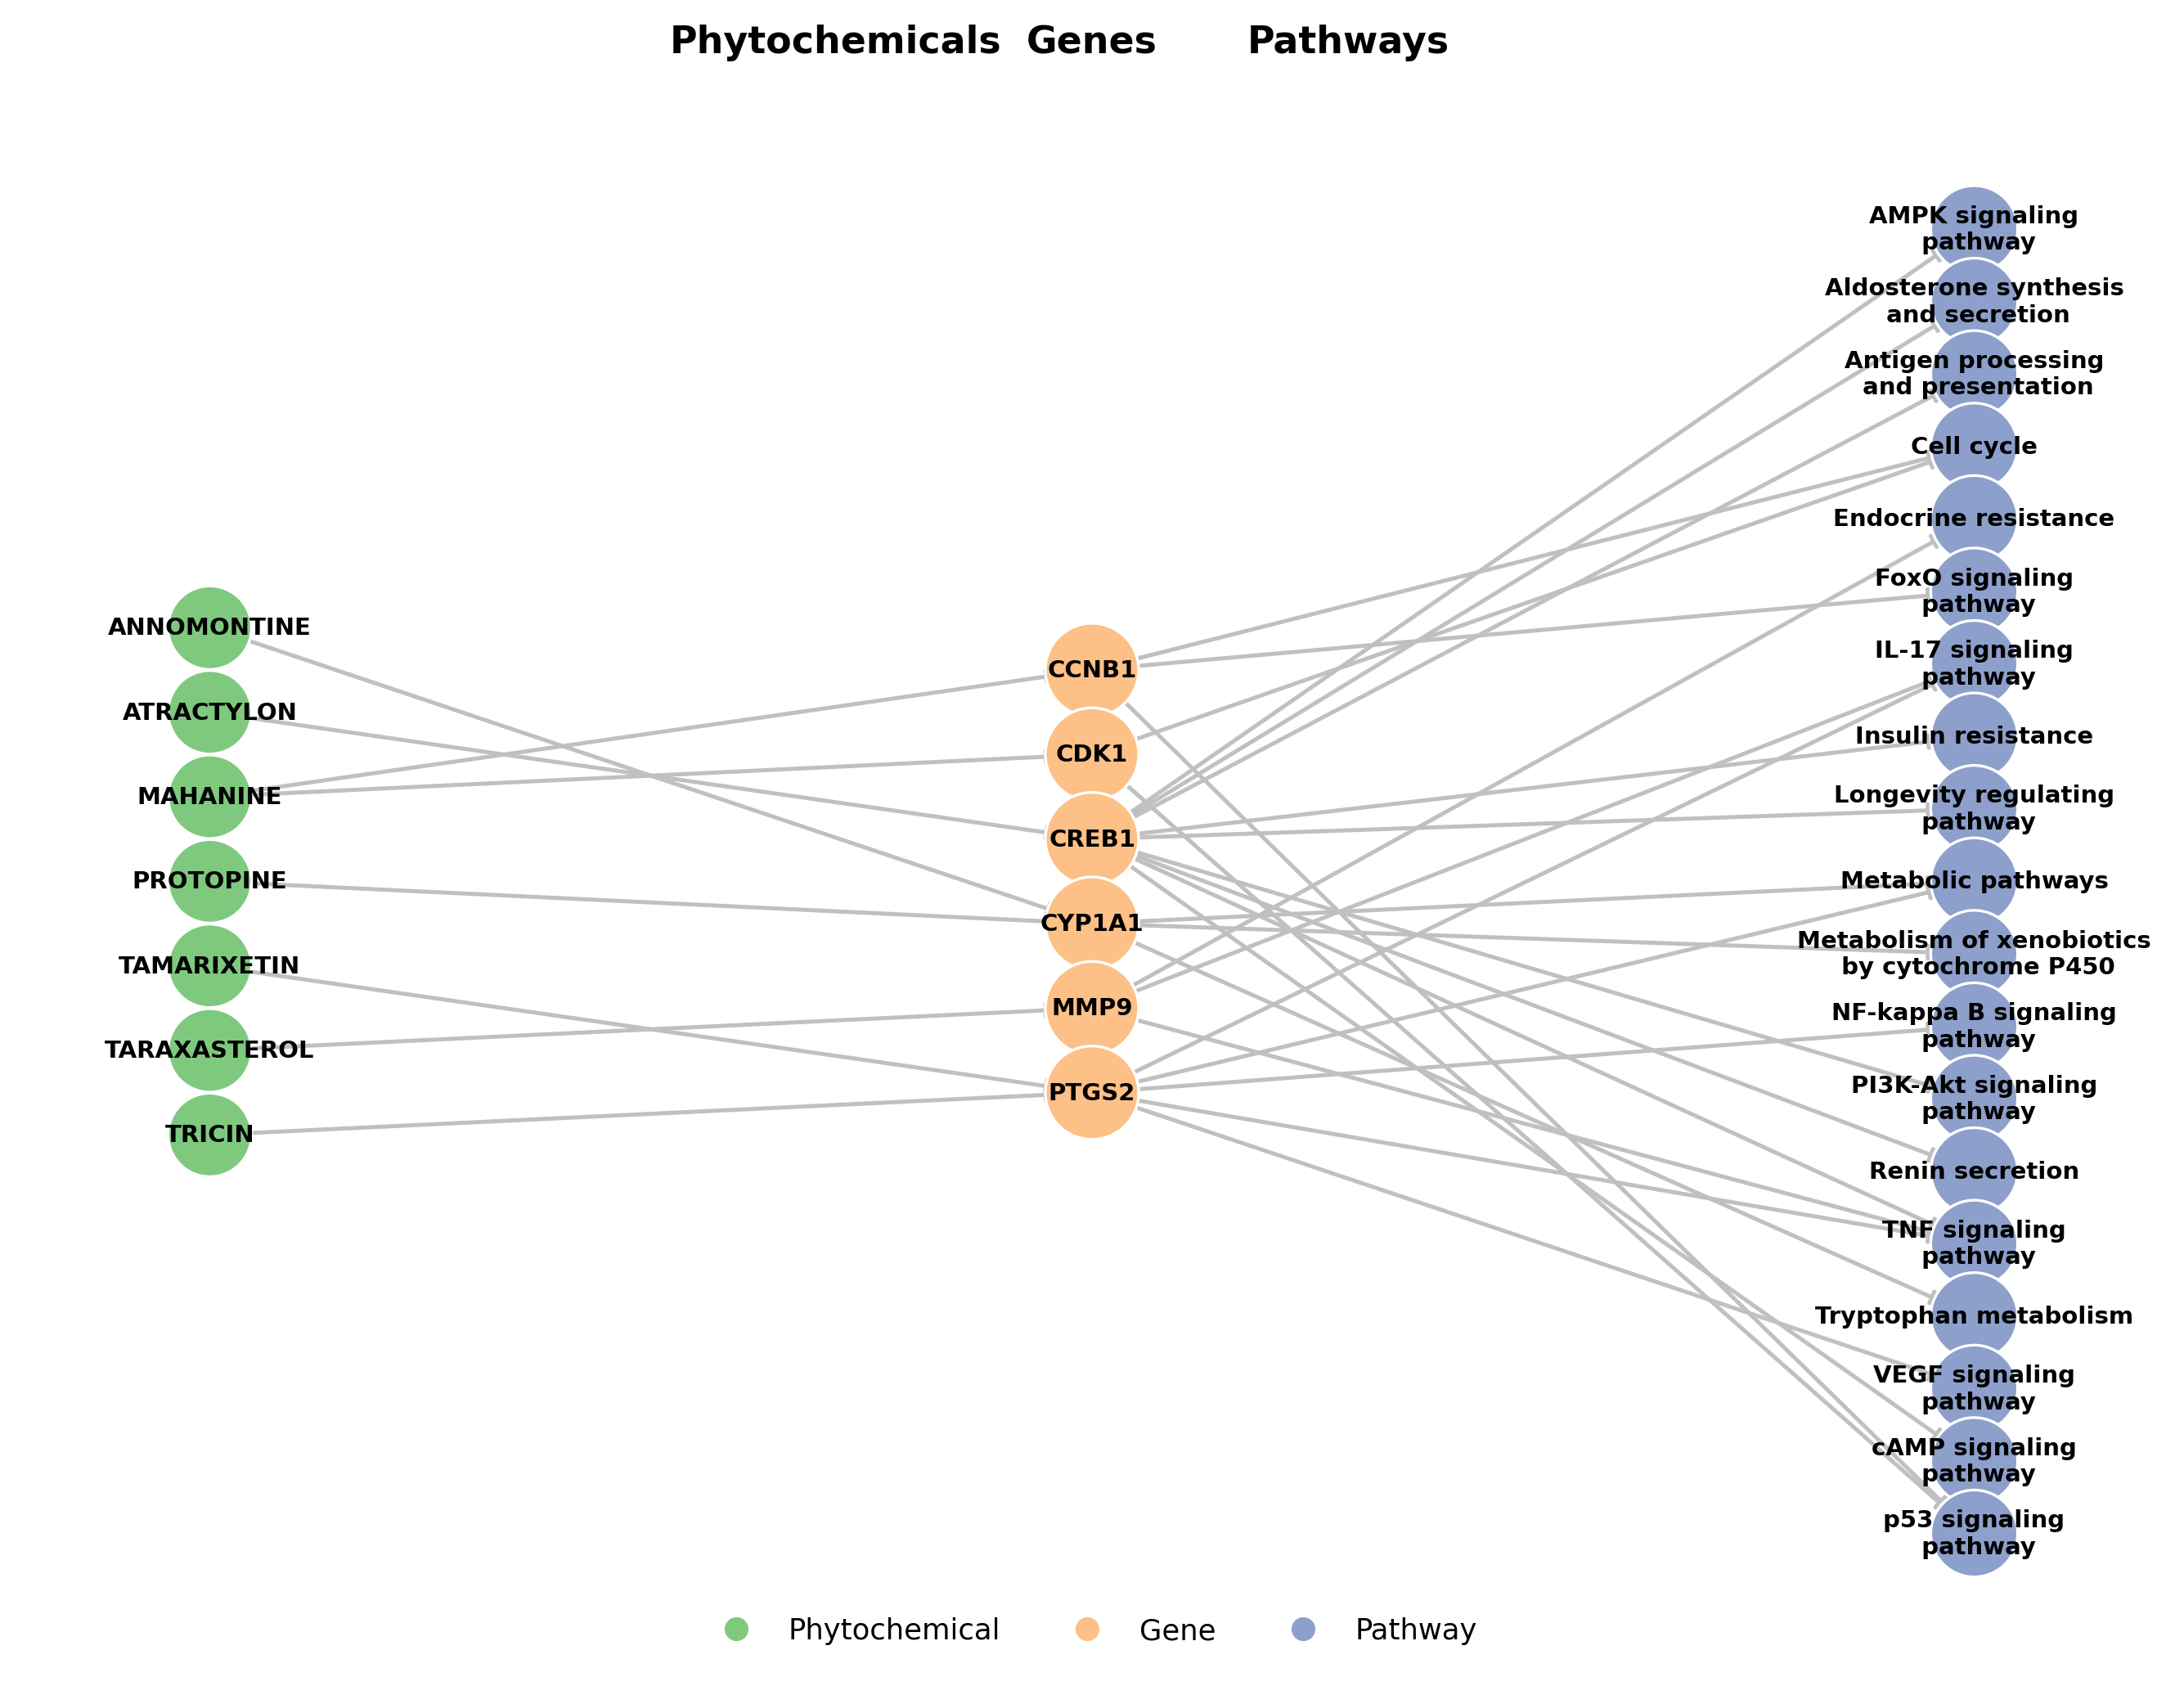

In [2]:
# -*- coding: utf-8 -*-
# Tripartite network (short edges): Phytochemical → Gene → Pathway

import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.lines import Line2D

# -----------------------------
# 1) Data
# -----------------------------
chem_gene_edges = [
    ("Mahanine", "CCNB1"),
    ("Mahanine", "CDK1"),
    ("Taraxasterol", "MMP9"),
    ("Tricin", "PTGS2"),
    ("Tamarixetin", "PTGS2"),
    ("Annomontine", "CYP1A1"),
    ("Protopine", "CYP1A1"),
    ("Atractylon", "CREB1"),
]

gene_pathway_edges = [
    ("CREB1", "Aldosterone synthesis\n and secretion"),
    ("CREB1", "AMPK signaling\n pathway"),
    ("CREB1", "Antigen processing\n and presentation"),
    ("CREB1", "cAMP signaling\n pathway"),
    ("CCNB1", "Cell cycle"),
    ("CDK1",  "Cell cycle"),
    ("MMP9",  "Endocrine resistance"),
    ("CCNB1", "FoxO signaling\n pathway"),
    ("MMP9",  "IL-17 signaling\n pathway"),
    ("PTGS2", "IL-17 signaling\n pathway"),
    ("CREB1", "Insulin resistance"),
    ("CREB1", "Longevity regulating\n pathway"),
    ("PTGS2", "Metabolic pathways"),
    ("CYP1A1","Metabolic pathways"),
    ("CYP1A1","Metabolism of xenobiotics\n by cytochrome P450"),
    ("PTGS2", "NF-kappa B signaling\n pathway"),
    ("CCNB1", "p53 signaling\n pathway"),
    ("CDK1",  "p53 signaling\n pathway"),
    ("CREB1", "PI3K-Akt signaling\n pathway"),
    ("CREB1", "Renin secretion"),
    ("MMP9",  "TNF signaling\n pathway"),
    ("PTGS2", "TNF signaling\n pathway"),
    ("CREB1", "TNF signaling\n pathway"),
    ("CYP1A1","Tryptophan metabolism"),
    ("PTGS2", "VEGF signaling\n pathway"),
]

# -----------------------------
# 2) Build graph
# -----------------------------
G = nx.DiGraph()
chemicals = sorted({c for c, _ in chem_gene_edges})
genes     = sorted({g for _, g in chem_gene_edges} | {g for g, _ in gene_pathway_edges})
pathways  = sorted({p for _, p in gene_pathway_edges})

G.add_nodes_from(chemicals, layer="Phytochemical")
G.add_nodes_from(genes,     layer="Gene")
G.add_nodes_from(pathways,  layer="Pathway")
G.add_edges_from(chem_gene_edges)
G.add_edges_from(gene_pathway_edges)

# -----------------------------
# 3) Compact column layout
#    (short edges: bring columns close)
# -----------------------------
X_LEFT, X_MID, X_RIGHT = 0.38, 0.50, 0.62   # << shorten/lengthen edges by moving these
Y_SP_CHEM, Y_SP_GENE, Y_SP_PATH = 0.07, 0.07, 0.06

def column_positions(items, x_value, spacing):
    n = len(items)
    if n == 1:
        ys = [0.5]
    else:
        ys = np.linspace(0.5 + spacing*(n-1)/2, 0.5 - spacing*(n-1)/2, n)
    return {item: (x_value, y) for item, y in zip(items, ys)}

pos = {}
pos.update(column_positions(chemicals, X_LEFT,  Y_SP_CHEM))
pos.update(column_positions(genes,     X_MID,   Y_SP_GENE))
pos.update(column_positions(pathways,  X_RIGHT, Y_SP_PATH))

# -----------------------------
# 4) Style
# -----------------------------
color_map = {"Phytochemical": "#7FC97F", "Gene": "#FDC086", "Pathway": "#8DA0CB"}
node_colors = [color_map[G.nodes[n]["layer"]] for n in G.nodes()]
node_sizes = [600 if G.nodes[n]["layer"]=="Phytochemical"
              else 750 if G.nodes[n]["layer"]=="Gene"
              else 650 for n in G.nodes()]

# -----------------------------
# 5) Draw
# -----------------------------
fig, ax = plt.subplots(figsize=(9.0, 7.0), dpi=300)  # slightly narrower figure

# Edges (light grey, short distance due to tight columns)
nx.draw_networkx_edges(
    G, pos, edge_color="#c0c0c0", width=1.2, arrows=True,
    arrowstyle="-|>", arrowsize=9, connectionstyle="arc3,rad=0.0", ax=ax
)

# Nodes
nx.draw_networkx_nodes(
    G, pos, node_size=node_sizes, node_color=node_colors,
    edgecolors="white", linewidths=0.8, ax=ax
)

# Labels
labels = {n: (n.upper() if G.nodes[n]["layer"]=="Phytochemical" else n) for n in G.nodes()}
nx.draw_networkx_labels(G, pos, labels=labels, font_size=7, font_weight="bold", ax=ax)

# Column headers
ax.text(X_LEFT,  1.02, "Phytochemicals", ha="center", va="bottom",
        fontsize=11, fontweight="bold", transform=ax.transAxes)
ax.text(X_MID,   1.02, "Genes", ha="center", va="bottom",
        fontsize=11, fontweight="bold", transform=ax.transAxes)
ax.text(X_RIGHT, 1.02, "Pathways", ha="center", va="bottom",
        fontsize=11, fontweight="bold", transform=ax.transAxes)

# Legend
legend_handles = [
    Line2D([0], [0], marker='o', color='w', label='Phytochemical',
           markerfacecolor=color_map["Phytochemical"], markersize=8),
    Line2D([0], [0], marker='o', color='w', label='Gene',
           markerfacecolor=color_map["Gene"], markersize=8),
    Line2D([0], [0], marker='o', color='w', label='Pathway',
           markerfacecolor=color_map["Pathway"], markersize=8),
]
ax.legend(handles=legend_handles, loc="lower center", frameon=False, fontsize=8.5, ncol=3)

ax.set_axis_off()

# keep generous left/right margins so long pathway names don't clip
plt.subplots_adjust(left=0.08, right=0.92, top=0.93, bottom=0.08)
plt.tight_layout()

# -----------------------------
# 6) Save
# -----------------------------
out_png = "Tripartite_PhytoGenePathway_SHORT_EDGES_300dpi.png"
plt.savefig(out_png, dpi=300, bbox_inches="tight")
print(f"✅ Saved: {out_png}")

# (optional) export edges
pd.DataFrame(chem_gene_edges, columns=["Phytochemical","Gene"]).to_csv("edges_Phytochemical_Gene.csv", index=False)
pd.DataFrame(gene_pathway_edges, columns=["Gene","Pathway"]).to_csv("edges_Gene_Pathway.csv", index=False)
